In [5]:
# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Loading the dataset
df = pd.read_csv('../data_jobs.csv')

#### Data Cleaning

In [6]:
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda skill_list: ast.literal_eval(skill_list) if pd.notna(skill_list) else skill_list)

#### Filtering Only India Data Analyst roles

In [8]:
df_DA_India = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'India') ].copy()

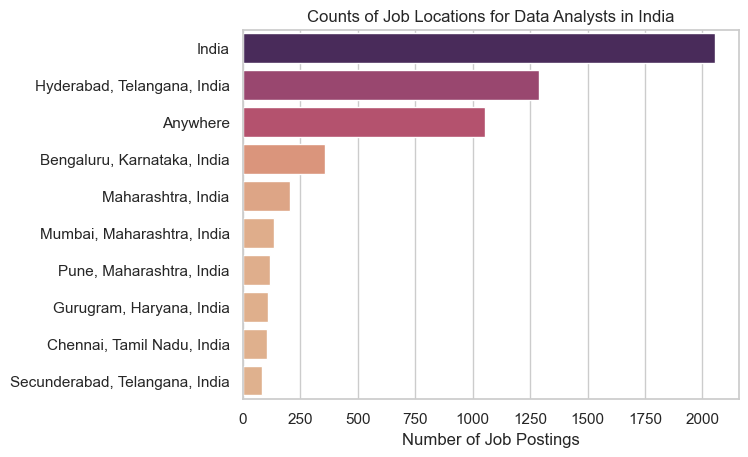

In [44]:
df_plot = df_DA_India['job_location'].value_counts().head(10).to_frame()

sns.set_theme(style="whitegrid")
sns.barplot(data = df_plot, x='count', y='job_location', hue='count', palette='flare', legend=False)
plt.title('Counts of Job Locations for Data Analysts in India')
plt.xlabel('Number of Job Postings')
plt.ylabel('')
plt.show()

### Job Opportunities

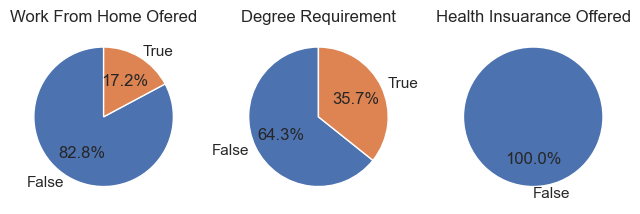

In [51]:


dict_column={
    'job_work_from_home':'Work From Home Ofered',
    'job_no_degree_mention':'Degree Requirement',
    'job_health_insurance':'Health Insuarance Offered'
}

fig, ax =plt.subplots(1,3)


for i, (column, title) in enumerate(dict_column.items()):
    counts = df_DA_India[column].value_counts()   # Getting the actual counts present in the data
    labels = [str(index) for index in counts.index] # DYNAMIC LABELS: This pulls ['False', 'True'] or just ['False'] depending on what's actually there
    ax[i].pie(counts, startangle=90, autopct='%1.1f%%', labels=labels) # Passing the dynamic labels
    ax[i].set_title(title)

fig.tight_layout()
plt.show()

### Companie to Explore

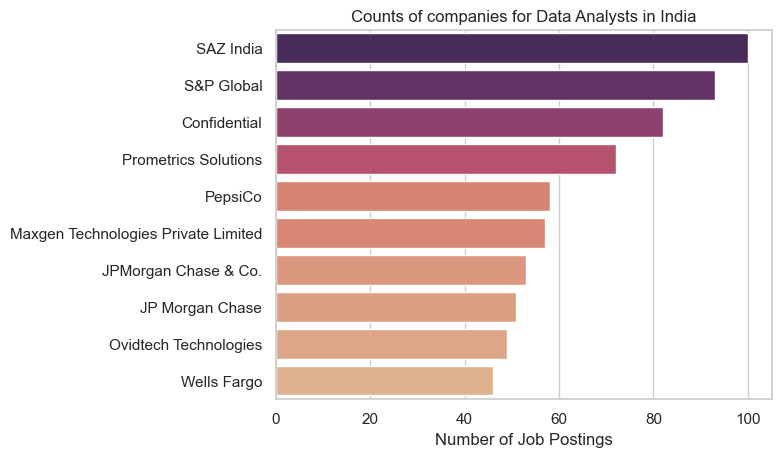

In [54]:
df_plot = df_DA_India['company_name'].value_counts().head(10).to_frame()

sns.set_theme(style="whitegrid")
sns.barplot(data = df_plot, x='count', y='company_name', hue='count', palette='flare', legend=False)
plt.title('Counts of companies for Data Analysts in India')
plt.xlabel('Number of Job Postings')
plt.ylabel('')
plt.show()